# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DEEPIKA-Inag/Flyrank-internship/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

### My approach & findings

Key fields: `impressions_90d`, `clicks_90d`, `sessions_90d` (GSC/GA4 90-day totals), `word_count`, `ctr`, `avg_position`, `engagement_rate` — read from `data/raw/content_refresh_anonymized.csv` (30,000 rows).

**Heavy tails, confirmed.** For every traffic count, mean >> median and the max dwarfs everything else:

| field | mean | median | p90 | p99 | max |
|---|---|---|---|---|---|
| impressions_90d | 5,200 | 731 | 12,136 | 73,506 | 517,715 |
| clicks_90d | 16.1 | 1 | 32 | 253 | 4,178 |
| sessions_90d | 37.1 | 7 | 88 | 451 | 4,345 |

A handful of giant pages carry most of the traffic; the typical page is far smaller than the mean suggests. `ctr` and `engagement_rate` show the same shape (max 100, median near 0).

**One sentinel-zero trap caught here, not later.** `avg_position == 0` means "no position data," not rank zero (1,205 rows, matching the data dictionary). Left in, those rows quietly change results twice: they drag the raw mean from 17.0 down to 16.3, and — because the tiering rule uses `avg_position <= 3` for `top_3` — all 1,205 of them get miscategorized as `top_3` instead of excluded. Test 1 below filters them out.

Given the skew, everything downstream uses `log1p`/medians for counts and **weighted** rates (sum of numerator over sum of denominator per group) instead of raw means or means-of-per-row-rates.

30,000 rows x 44 columns
                    mean   median       p90       p99       max
impressions_90d  5200.37   731.00  12136.40  73505.83  517715.0
clicks_90d         16.10     1.00     32.00    253.01    4178.0
sessions_90d       37.07     7.00     88.00    451.01    4345.0
word_count       3107.76  2877.00   5327.00   7292.00    9546.0
ctr                 0.51     0.07      0.65      8.33     100.0
avg_position       16.34    10.80     36.80     69.90     245.0
engagement_rate     2.53     0.00      6.94     33.33     100.0

mean/median ratio (bigger = heavier tail):
  impressions_90d: 7.1x
  clicks_90d: 16.1x
  sessions_90d: 5.3x

avg_position == 0 ('no position data') rows: 1205
where the tiering rule sends them:
position_tier
top_3    1205
Name: count, dtype: int64
avg_position mean including zeros: 16.34  excluding zeros: 17.03


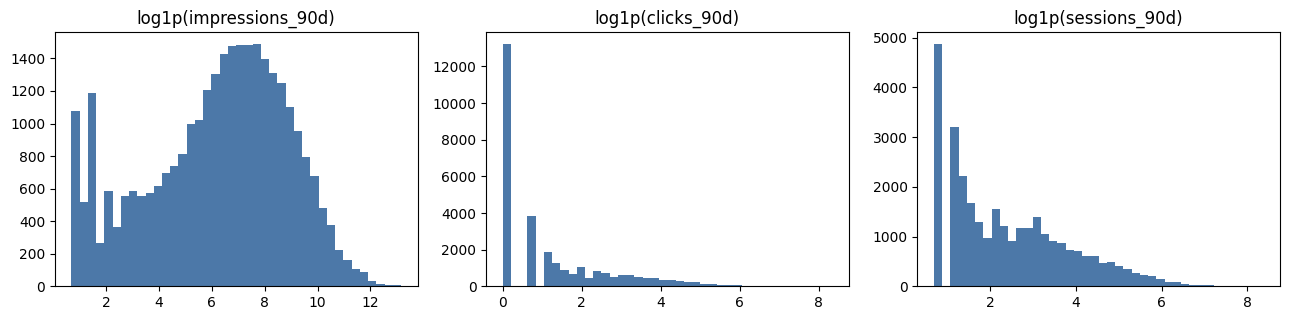

In [1]:
# Section 1 -- distributions of the key fields
import os
import pandas as pd, numpy as np

RAW_LOCAL = "data/raw/content_refresh_anonymized.csv"
RAW_URL = (
"https://raw.githubusercontent.com/DEEPIKA-Inag/Flyrank-internship/"
"main/data/raw/content_refresh_anonymized.csv"
)
df = pd.read_csv(RAW_LOCAL if os.path.exists(RAW_LOCAL) else RAW_URL)
print(f"{df.shape[0]:,} rows x {df.shape[1]} columns")

key_fields = ["impressions_90d", "clicks_90d", "sessions_90d", "word_count", "ctr", "avg_position", "engagement_rate"]
summary = pd.DataFrame({
"mean": df[key_fields].mean(),
"median": df[key_fields].median(),
"p90": df[key_fields].quantile(0.90),
"p99": df[key_fields].quantile(0.99),
"max": df[key_fields].max(),
}).round(2)
print(summary)

print(f"\nmean/median ratio (bigger = heavier tail):")
for c in ["impressions_90d", "clicks_90d", "sessions_90d"]:
    print(f"  {c}: {df[c].mean() / df[c].median():.1f}x")


print(f"\navg_position == 0 ('no position data') rows: {(df['avg_position'] == 0).sum()}")
print("where the tiering rule sends them:")
print(df.loc[df["avg_position"] == 0, "position_tier"].value_counts())
print(f"avg_position mean including zeros: {df['avg_position'].mean():.2f}  excluding zeros: {df.loc[df['avg_position'] > 0, 'avg_position'].mean():.2f}")

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(13, 3.3))
for ax, col in zip(axes, ["impressions_90d", "clicks_90d", "sessions_90d"]):
    ax.hist(np.log1p(df[col]), bins=40, color="#4C78A8")
    ax.set_title(f"log1p({col})")
plt.tight_layout()
plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

### Test 1 — "Better search position gets you a better click-through rate"

**Claim:** pages ranked closer to #1 get clicked on more per impression.
**Test:** weighted CTR (`sum(clicks_90d) / sum(impressions_90d)` per `position_tier`, never the mean of each page's own `ctr` — that would let thousands of tiny-volume pages outvote the few that carry the actual clicks), on the 28,795 rows with real position data (`avg_position > 0`, per Section 1's sentinel-zero trap).

| position_tier | n | weighted CTR |
|---|---|---|
| top_3 | 1,116 | 0.489% |
| page_1 | 11,814 | 0.350% |
| striking | 7,304 | 0.347% |
| page_3_5 | 7,242 | 0.155% |
| deep | 1,319 | 0.041% |

CTR steps down monotonically from top_3 to deep — an ~12x gap top-to-bottom — and every tier clears the n≥50 floor by a wide margin. **Verdict: CONFIRMED.**

### Test 2 — "Longer articles pull more organic search traffic"

**Claim:** word count and impressions move together.
**Test:** both sides are heavy-tailed (Section 1), so I used `word_count_tier` group medians plus a rank-based (Spearman) correlation on the 22,301 rows with a recorded word count.

| word_count_tier | n | median impressions_90d |
|---|---|---|
| <1000 | 973 | 4 |
| 1000-2000 | 3,780 | 172 |
| 2000-3500 | 11,263 | 997 |
| 3500+ | 6,285 | 1,340 |

Median impressions climb at every step, and Spearman ρ = 0.299 (n = 22,301, p < 0.001) confirms a real, positive, monotonic relationship. But ρ = 0.30 is modest, not strong, and word count is confounded with `content_type` (short pieces skew toward `feedly article`, which also carries no keyword targeting at all). **Verdict: CONFIRMED — directional, weak-to-moderate, not causal.**

### Test 3 — "Stale pages (not updated in a while) are more likely to be declining"

**Claim:** the longer since a page was last updated, the more likely its trend is `down`.
**Test:** decline rate (`is_declining_label`) by `freshness_tier`.

| freshness_tier | n | decline rate |
|---|---|---|
| 0-30 | 20,480 | 0.511 |
| 31-90 | 175 | 0.589 |
| 91-180 | 9,171 | 0.611 |
| 181+ | 174 | 0.471 |

Not monotonic: the stalest bucket (`181+`) has a *lower* decline rate than `91-180`, and it and `31-90` are thin (n≈175 — just over the 50-row floor, nowhere near the volume of the other two tiers, so read those two as directional only). This matches ML-03's earlier finding that freshness only moves decline risk inside specific position tiers, not as a blanket rule. **Verdict: MIXED** — "just get staler" doesn't hold as a standalone story.

In [2]:
# Section 2 -- three signal tests, each with n's and a verdict
df["is_declining_label"] = (df["trend_direction"] == "down").astype(int)

# Test 1: position_tier -> weighted CTR (exclude avg_position==0 "no data" sentinel)
order_pos = ["top_3", "page_1", "striking", "page_3_5", "deep"]
g1 = df[df["avg_position"] > 0].groupby("position_tier")
test1 = pd.DataFrame({
"n": g1.size(),
"impressions_sum": g1["impressions_90d"].sum(),
"clicks_sum": g1["clicks_90d"].sum(),
})
test1["weighted_ctr_pct"] = (test1["clicks_sum"] / test1["impressions_sum"] * 100).round(3)
print("Test 1 -- position_tier -> weighted CTR")
print(test1.reindex(order_pos)[["n", "weighted_ctr_pct"]])

# Test 2: word_count_tier -> impressions (medians + Spearman, both heavy-tailed)
from scipy import stats
order_wc = ["<1000", "1000-2000", "2000-3500", "3500+"]
sub = df.dropna(subset=["word_count", "word_count_tier"])
g2 = sub.groupby("word_count_tier")
test2 = pd.DataFrame({"n": g2.size(), "median_impressions_90d": g2["impressions_90d"].median()})
print("\nTest 2 -- word_count_tier -> median impressions_90d")
print(test2.reindex(order_wc))
rho, p = stats.spearmanr(sub["word_count"], sub["impressions_90d"])
print(f"Spearman rho = {rho:.3f} (n={len(sub)}, p={p:.1e})")

# Test 3: freshness_tier -> decline rate
order_fresh = ["0-30", "31-90", "91-180", "181+"]
g3 = df.groupby("freshness_tier")
test3 = pd.DataFrame({"n": g3.size(), "decline_rate": g3["is_declining_label"].mean().round(3)})
print("\nTest 3 -- freshness_tier -> decline rate")
print(test3.reindex(order_fresh))
print(f"overall decline rate: {df['is_declining_label'].mean():.3f}")

Test 1 -- position_tier -> weighted CTR
                   n  weighted_ctr_pct
position_tier                         
top_3           1116             0.489
page_1         11814             0.350
striking        7304             0.347
page_3_5        7242             0.155
deep            1319             0.041

Test 2 -- word_count_tier -> median impressions_90d
                     n  median_impressions_90d
word_count_tier                               
<1000              973                     4.0
1000-2000         3780                   172.0
2000-3500        11263                   997.0
3500+             6285                  1340.0
Spearman rho = 0.299 (n=22301, p=0.0e+00)

Test 3 -- freshness_tier -> decline rate
                    n  decline_rate
freshness_tier                     
0-30            20480         0.511
31-90             175         0.589
91-180           9171         0.611
181+              174         0.471
overall decline rate: 0.542


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

### Flag: `low_ctr_visible_page` (from `scripts/02_baseline_score.py`)

Fires when `impressions_90d >= 500` AND `0 < avg_position <= 20` AND `ctr < 0.5`. **Assumption behind it:** a page that's genuinely visible and reasonably well-ranked but pulling an abnormally low CTR is underperforming and worth a review.

**Direction check.** Among the 12,023 pages that meet the visibility+position half of the rule (impressions ≥ 500, position 1–20), the ones the flag actually fires on (`ctr < 0.5`, n = 9,759) decline at 62.7%, vs. 47.5% for the ones it leaves alone (n = 2,264) — both n's comfortably clear the floor, and they sit on either side of the 54.2% base rate in the direction the rule assumes.

**But the fixed threshold doesn't hold up.** Test 1 already showed "normal" CTR isn't flat across positions — it runs from ~0.49% at top_3 down to ~0.16% at striking. A single global cutoff of 0.5% ignores that, and the fallout shows: the flag fires on 75–85% of eligible pages at *every* position tier, not a distinctive minority.

| position_tier | n eligible | flag rate |
|---|---|---|
| top_3 | 458 | 0.751 |
| page_1 | 7,064 | 0.791 |
| striking | 4,485 | 0.850 |

**Verdict: MIXED.** The direction is right — flagged pages really do decline more often — but the flat threshold sits below "normal" for every tier, so the rule over-flags rather than isolating genuine outliers. A per-tier threshold (relative to each tier's own weighted CTR from Test 1) would sharpen this considerably.

In [3]:
# Section 3 -- flag-linked test: low_ctr_visible_page
eligible = df[(df["impressions_90d"] >= 500) & (df["avg_position"] > 0) & (df["avg_position"] <= 20)].copy()
eligible["flagged"] = eligible["ctr"] < 0.5

direction = eligible.groupby("flagged").agg(
n=("is_declining_label", "size"),
decline_rate=("is_declining_label", "mean"),
median_ctr=("ctr", "median"),
).round(3)
print("Direction check (eligible = impressions>=500 & position 1-20):")
print(direction)
print(f"overall base rate: {df['is_declining_label'].mean():.3f}")

calibration = eligible.groupby("position_tier")["flagged"].agg(n="size", flag_rate="mean").round(3)
print("\nCalibration -- flag rate by position tier (a selective flag should be low, not 75%+):")
print(calibration.reindex(["top_3", "page_1", "striking"]))

Direction check (eligible = impressions>=500 & position 1-20):
            n  decline_rate  median_ctr
flagged                                
False    2264         0.475        0.73
True     9759         0.627        0.17
overall base rate: 0.542

Calibration -- flag rate by position tier (a selective flag should be low, not 75%+):
                  n  flag_rate
position_tier                 
top_3           458      0.751
page_1         7064      0.791
striking       4485      0.850


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

Treat these flags as **directional triage, not a diagnosis**. `low_ctr_visible_page` does point at pages that decline more often (62.7% vs. 47.5%), so it's reasonable for sorting a weekly review queue — but because it fires on 4 out of every 5 eligible pages, "flagged" shouldn't read as "broken." A page's CTR is worth judging against its own position tier's norm (the ~0.49% / 0.35% / 0.35% / 0.16% / 0.04% ladder from Test 1), not one global 0.5% line, or the queue fills up with page-1 content that's actually performing normally. The same caution applies to staleness: "refresh anything old" isn't backed by Test 3 on its own — it only earns a slot when it's paired with the position/visibility context ML-03 already surfaced.

In [4]:
# Section 4 -- scorecard tying the four verdicts together
print("Signal audit scorecard")
print("-" * 52)
print(f"{'Test 1  position -> CTR':34s} CONFIRMED")
print(f"{'Test 2  word count -> impressions':34s} CONFIRMED (weak, rho=0.30)")
print(f"{'Test 3  freshness -> decline rate':34s} MIXED (not monotonic)")
print(f"{'Flag    low_ctr_visible_page':34s} MIXED (right direction, loose threshold)")

Signal audit scorecard
----------------------------------------------------
Test 1  position -> CTR            CONFIRMED
Test 2  word count -> impressions  CONFIRMED (weak, rho=0.30)
Test 3  freshness -> decline rate  MIXED (not monotonic)
Flag    low_ctr_visible_page       MIXED (right direction, loose threshold)


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.